# Análisis Exploratorio — Sistema de Recomendación de Películas

**Introducción al Procesamiento del Lenguaje Natural — TFI 1C 2026**

Este notebook explora los dos insumos del trabajo antes de tomar decisiones de diseño:

1. El **corpus** `mathigatti/spanish_imdb_synopsis` (`data/plots.csv`): ~5.000 películas con sinopsis, keywords, género, año y director.
2. Los **perfiles de usuario** (`data/perfiles_usuarios.csv`): 14 usuarios, cada uno con 5 películas vistas y una *query* en lenguaje natural.

El objetivo no es solo describir los datos, sino **detectar las limitaciones estructurales que condicionan las decisiones metodológicas** posteriores (representación, modelado del usuario y evaluación). Las preguntas que la consigna plantea sobre el corpus se responden aquí.


## Anclaje con la materia

Cada celda de código lleva una nota **📚 Anclaje** que la vincula con la unidad donde se vio la técnica. En síntesis para este notebook:

- **Carga e inspección del corpus** con `pandas` → Unidad 1.
- **Análisis de frecuencias y visualización** (longitudes, conteo de géneros) → Unidad 2 (frecuencias de palabras, Ley de Zipf).
- **Normalización de texto** (`unidecode` + regex) → la misma limpieza de Unidades 1–2, aplicada acá a títulos.
- **Consideración de idioma mixto / stopwords** → Unidades 1–2.

Lo que **no** sale del temario de NLP se marca explícitamente: el **matching difuso de títulos** (`rapidfuzz`) es *record linkage* (ingeniería de datos), incluido por necesidad y señalado como aporte propio.


## 1. Carga de datos

> 📚 **Anclaje — carga del corpus (Unidad 1).** Lectura y primera inspección de un corpus con `pandas`, como en la exploración inicial de U1.

In [1]:
import os
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 90)

DATA = "data"
df = pd.read_csv(os.path.join(DATA, "plots.csv"))
users = pd.read_csv(os.path.join(DATA, "perfiles_usuarios.csv"))

print(f"Corpus:   {df.shape[0]} películas, {df.shape[1]} columnas")
print(f"Perfiles: {users.shape[0]} usuarios")
df.head(3)

Corpus:   4967 películas, 6 columnas
Perfiles: 14 usuarios


,description,keywords,genre,year,name,director
0,"Orin Boyd, un duro policía de una comisaría del centro de la ciudad, descubre una red ...","vietnam war veteran, heroína, drogas, narcotraficante, corrupt cop","acción, crimen, suspense",2001.0,Herida abierta,Andrzej Bartkowiak
1,"Al llegar a un pequeño pueblo donde ha heredado una mansión en ruinas, una famosa anfi...","herencia, hostess, comedia negra, pueblo, magia","comedia, terror",1989.0,"Elvira, reina de las tinieblas",James Signorelli
2,"Una mujer finge su muerte en un intento de escapar de su horrible matrimonio, pero des...","violencia doméstica, muerte fingida, borderline personality disorder, relación madre h...","drama, suspense",1991.0,Durmiendo con su enemigo,Joseph Ruben


## 2. Calidad del corpus

Antes de elegir cómo representar las películas, hay que saber con qué contamos. La consigna pregunta: *¿qué tan completo y limpio es el corpus y qué consecuencias tiene?* Miramos nulos, duplicados y rangos.

> 📚 **Anclaje — conocer los datos antes de procesarlos (Unidad 1).** Revisar nulos, duplicados y rangos es el paso previo a cualquier limpieza; en U1 todo arranca por inspeccionar el corpus.

In [2]:
print("Valores nulos por columna:")
print(df.isna().sum())
print()
print(f"Nombres duplicados:        {df['name'].duplicated().sum()}")
print(f"Sinopsis vacías/<20 chars: {(df['description'].fillna('').str.len() < 20).sum()}")
print(f"Rango de años:             {df['year'].min():.0f} – {df['year'].max():.0f}")

Valores nulos por columna:
description      0
keywords         0
genre            0
year            34
name             0
director       500
dtype: int64

Nombres duplicados:        61
Sinopsis vacías/<20 chars: 0
Rango de años:             1981 – 2022


**Lectura.** Los tres campos textuales —`description`, `keywords`, `genre`— y `name` no tienen nulos: son la base confiable. En cambio `director` tiene ~10% de faltantes y `year` algunos, por lo que son señales secundarias o de filtrado, no de contenido. Los **nombres duplicados** son una advertencia temprana: cualquier operación que cruce por título (como excluir el historial del usuario) puede confundir películas. Conviene trabajar con un índice interno, no con el nombre.

## 3. Los campos como señal de contenido

No toda la información es igualmente útil. Comparamos los tres campos textuales para decidir cuáles alimentan la representación.

> 📚 **Anclaje — estadística de frecuencias del texto (Unidad 2).** Medir longitud de sinopsis y cantidad de keywords es análisis de frecuencias, en la línea de los conteos de palabras de U2.

In [3]:
df["len_desc"] = df["description"].str.len()
df["len_kw"]   = df["keywords"].str.len()
print("Longitud de la sinopsis (caracteres):")
print(df["len_desc"].describe()[["mean", "50%", "min", "max"]].round(0))
print()
print("Cantidad de keywords por película:")
df["n_kw"] = df["keywords"].str.split(",").apply(len)
print(df["n_kw"].describe()[["mean", "50%", "min", "max"]].round(1))

Longitud de la sinopsis (caracteres):
mean    154.0
50%     152.0
min      33.0
max     258.0
Name: len_desc, dtype: float64

Cantidad de keywords por película:
mean    5.0
50%     5.0
min     2.0
max     7.0
Name: n_kw, dtype: float64


> 📚 **Anclaje — inspección cualitativa del texto (Unidad 1).** Mirar ejemplos crudos antes de decidir el preprocesamiento, como en U1.

In [4]:
# Ejemplo concreto: los tres campos para una misma película
ej = df.iloc[2]
print("PELÍCULA:", ej["name"], f"({ej['year']:.0f})")
print("\nGENRE   :", ej["genre"])
print("\nKEYWORDS:", ej["keywords"])
print("\nDESCRIPTION:\n", ej["description"])

PELÍCULA: Durmiendo con su enemigo (1991)

GENRE   : drama, suspense

KEYWORDS: violencia doméstica, muerte fingida, borderline personality disorder, relación madre hija, psico-thriller

DESCRIPTION:
 Una mujer finge su muerte en un intento de escapar de su horrible matrimonio, pero descubre que es imposible evitar a su controlador marido.


**Lectura.** Las sinopsis son texto libre y relativamente cortas (un par de oraciones): describen la *trama puntual*, no necesariamente el *tono* o el *tipo* de película. Las **keywords son el campo más valioso**: son tags curados que ya condensan los conceptos clave que un sistema de NLP intentaría inferir desde cero (`violencia doméstica`, `psycho-thriller`, `manic pixie dream girl`). Y `genre` da la categoría gruesa. Usar los tres juntos da una representación más rica que la sinopsis sola.

> 📚 **Anclaje — conteo y visualización de frecuencias (Unidad 2 c2).** Mismo patrón que los gráficos de términos por TF/Zipf de U2: contar las categorías más frecuentes y graficarlas con un *barplot* horizontal.

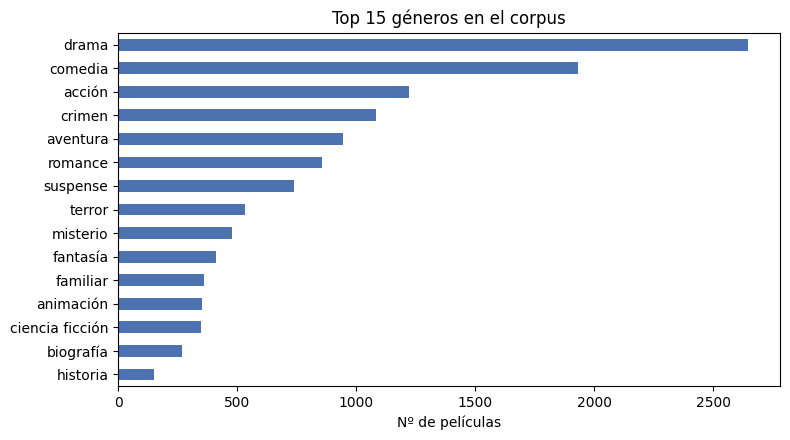

In [5]:
# Géneros más frecuentes (genre es multi-etiqueta, separado por comas)
generos = Counter()
for g in df["genre"].dropna():
    for x in g.split(","):
        generos[x.strip()] += 1
top_gen = pd.Series(dict(generos)).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 4.5))
top_gen[::-1].plot.barh(ax=ax, color="#4C72B0")
ax.set_title("Top 15 géneros en el corpus")
ax.set_xlabel("Nº de películas")
plt.tight_layout(); plt.show()

### Un detalle que condiciona la representación: idioma mixto

El corpus es "en español", pero las **keywords mezclan español e inglés** de forma sistemática. Esto afecta a cualquier representación: el preprocesamiento (stopwords, stemming) y el vocabulario tienen que convivir con los dos idiomas.

> 📚 **Anclaje — el idioma condiciona el preprocesamiento (Unidades 1–2).** La tokenización y las stopwords dependen del idioma; detectar acá el español+inglés anticipa decisiones del pipeline de U1–U2.

In [6]:
# Muestra de keywords con términos en inglés intercalados
muestra = df["keywords"].dropna().sample(6, random_state=1).tolist()
for k in muestra:
    print("•", k)

• comedy of manners, drama histórico, identidad falsa, amor, farsa
• female full frontal nudity, murder of a nude woman, braguitas bajadas, hit by a car, sexo por la puerta de atrás
• president, política, Navidad, salir de citas, referencia a Franklin D Roosevelt
• casualty notification team, respect, hooded sweatshirt, rutina de ejercicio, viendo la tele
• bare breasts, escena sexual, female nudity, ankle holster, murder of a nude woman
• papadum, asesinato, India, non professional cast, prostitute


## 4. Los perfiles de usuario

Cada usuario tiene 5 películas vistas (`historial`) y una `query` en lenguaje natural. La columna `tipo_perfil` los divide en **definidos** (preferencias claras) y **ambiguos** (historial disperso, query vaga). Esa distinción es central: el sistema no debería tratar igual a los dos.

> 📚 **Anclaje — datos propios del TP (sin técnica de clase asociada).** Exploración de los perfiles provistos por la cátedra.

In [7]:
print(users["tipo_perfil"].value_counts(), "\n")
for _, r in users.iterrows():
    hist = " | ".join(str(r[f"pelicula_{i}"]) for i in range(1, 6))
    print(f"[{r['tipo_perfil']:8}] {r['nombre']:10} → {r['query'][:70]}")

tipo_perfil
definido    10
ambiguo      4
Name: count, dtype: int64 

[definido] Valentina  → Quiero una película donde una mujer enfrenta una amenaza invisible que
[definido] Rodrigo    → Busco algo basado en hechos reales sobre corrupción o poder político
[definido] Camila     → Una comedia donde la relación entre dos personas empieza de forma ridí
[definido] Tomás      → Algo que haga pensar sobre qué es real y qué es una construcción, con 
[definido] Lucía      → Animación donde el protagonista lucha por su libertad o identidad en u
[definido] Martín     → Un grupo de personas planea un robo o estafa y las cosas se complican 
[definido] Sofía      → Una película sobre músicos o artistas que viven al margen, con mucha a
[definido] Diego      → Acción directa con un héroe que trabaja solo o casi solo contra una or
[definido] Elena      → Algo tranquilo sobre personas que intentan reconectar o entenderse des
[definido] Facundo    → Algo que sea difícil de clasificar, con una lógica na

**Lectura.** Comparar U02 ("hechos reales sobre corrupción o poder político", historial de dramas/policiales coherentes) con U13 ("algo que pueda ver con amigos o solo, que no sea muy larga ni muy corta", historial que va de *Titanic* a *Kill Bill* a *Scary Movie*) muestra el problema: en los perfiles ambiguos **la query casi no aporta contenido temático** y el historial no apunta a un lugar único del espacio. La evaluación tendrá que ser distinta para cada tipo.

## 5. Cruce historial ↔ corpus: ¿están las películas vistas en el corpus?

Para modelar al usuario a partir de su historial necesitamos representar esas películas, y para eso tienen que estar en el corpus. Cruzamos los títulos. **El matching de títulos no es trivial**: hay diferencias de acentos, puntuación y localización. Vamos por capas, de lo seguro a lo dudoso.

> 📚 **Anclaje — comparación de conjuntos (fuera del temario de NLP).** El cruce exacto de títulos es *entity matching* / ingeniería de datos, no una técnica de las unidades.

In [8]:
# Películas únicas del historial
hist_cols = [c for c in users.columns if c.startswith("pelicula_")]
peliculas_hist = sorted({p for c in hist_cols for p in users[c].dropna()})
print(f"Películas únicas en los historiales: {len(peliculas_hist)}")

# Capa 1 — match exacto
en_corpus = set(df["name"])
faltan_exacto = [p for p in peliculas_hist if p not in en_corpus]
print(f"No resueltas por match exacto:       {len(faltan_exacto)}")

Películas únicas en los historiales: 64
No resueltas por match exacto:       10


> 📚 **Anclaje — normalización de texto (Unidades 1–2), aplicada a títulos.** `unidecode` + regex para sacar acentos y puntuación es el mismo tipo de limpieza de U1–U2; acá lo usamos para emparejar títulos en vez de para tokenizar sinopsis.

In [9]:
# Capa 2 — normalización (minúsculas, sin acentos, sin puntuación)
from unidecode import unidecode

def normalizar(s):
    s = unidecode(str(s)).lower()
    s = re.sub(r"[^a-z0-9 ]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

df["name_norm"] = df["name"].map(normalizar)
norm_a_original = {}
for nrm, orig in zip(df["name_norm"], df["name"]):
    norm_a_original.setdefault(nrm, orig)

resueltas_norm = {}
faltan = []
for p in faltan_exacto:
    pn = normalizar(p)
    if pn in norm_a_original:
        resueltas_norm[p] = norm_a_original[pn]
    else:
        faltan.append(p)

print("Resueltas por normalización (acentos/puntuación):")
for k, v in resueltas_norm.items():
    print(f'  "{k}"  →  "{v}"')
print(f"\nSiguen sin resolver: {len(faltan)} → {faltan}")

Resueltas por normalización (acentos/puntuación):
  "Amélie"  →  "Amelie"
  "Walker Texas Ranger"  →  "Walker, Texas Ranger"

Siguen sin resolver: 8 → ['El exorcista', 'El secreto de sus ojos', 'Intocable', 'Kill Bill', 'Mamma Mia!', 'Paddington', 'Rec', 'Una mente brillante']


La normalización recupera los casos de acentos y puntuación. Para el resto probamos **matching difuso**, pero con cuidado: un score alto no garantiza que sea la misma película.

> 📚 **Anclaje — aporte propio, fuera de la materia.** El matching difuso (`rapidfuzz`, distancia de strings) es una técnica de *record linkage*; se incluye por necesidad del cruce y se señala como decisión del grupo, no como contenido de clase.

In [10]:
from rapidfuzz import process, fuzz

choices = list(norm_a_original.keys())
print("Mejor candidato difuso para cada título no resuelto:\n")
for p in faltan:
    cand, score, _ = process.extractOne(normalizar(p), choices,
                                        scorer=fuzz.token_set_ratio)
    print(f'  "{p}"  →  "{norm_a_original[cand]}"   (score {score:.0f})')

Mejor candidato difuso para cada título no resuelto:

  "El exorcista"  →  "El exorcista III"   (score 100)
  "El secreto de sus ojos"  →  "Las Tortugas Ninja II: El secreto de los mocos verdes"   (score 74)
  "Intocable"  →  "Infalible"   (score 67)
  "Kill Bill"  →  "Kill Bill: Volumen 1"   (score 100)
  "Mamma Mia!"  →  "Mamma Mia! La película"   (score 100)
  "Paddington"  →  "Carrington"   (score 70)
  "Rec"  →  "Rescate"   (score 60)
  "Una mente brillante"  →  "Un plan brillante"   (score 78)


**Acá está la trampa del fuzzy matching ciego.** Algunos candidatos son correctos (*Kill Bill* → *Kill Bill: Volumen 1*: es la misma saga presente en el corpus). Pero otros son **falsos amigos**: *El exorcista* matchea con *El exorcista III* (¡que es la secuela, otra película!) y *Una mente brillante* con *Un plan brillante* (sin relación). Aceptar matches por score automático metería ruido en el historial del usuario.

Por eso resolvemos solo los que **confirmamos manualmente** y declaramos el resto como **ausencias reales**.

> 📚 **Anclaje — criterio humano (decisión del grupo).** La confirmación manual de los matches dudosos es una decisión metodológica, no una técnica; queda documentada para la defensa.

In [11]:
# Capa 3 — alias confirmados manualmente (saga/título presente en el corpus)
alias_confirmados = {
    "Kill Bill": "Kill Bill: Volumen 1",   # misma saga, presente en el corpus
}
# (El exorcista III, Un plan brillante, etc. son películas distintas: NO se aceptan)

resueltas_alias = {p: alias_confirmados[p] for p in faltan if p in alias_confirmados}
ausentes = [p for p in faltan if p not in alias_confirmados]

print("Resueltas por alias manual:")
for k, v in resueltas_alias.items():
    print(f'  "{k}"  →  "{v}"')
print(f"\nAUSENCIAS REALES (no están en el corpus): {len(ausentes)}")
for a in ausentes:
    print(" •", a)

Resueltas por alias manual:
  "Kill Bill"  →  "Kill Bill: Volumen 1"

AUSENCIAS REALES (no están en el corpus): 7
 • El exorcista
 • El secreto de sus ojos
 • Intocable
 • Mamma Mia!
 • Paddington
 • Rec
 • Una mente brillante


> 📚 **Anclaje — reproducibilidad (buena práctica transversal).** Persistimos el mapa título→corpus para que los notebooks de recomendación lo reutilicen sin repetir el cruce.

In [12]:
# Mapa final título_usuario → título_corpus (lo usarán los notebooks de recomendación)
mapa_titulos = {p: p for p in peliculas_hist if p in en_corpus}
mapa_titulos.update(resueltas_norm)
mapa_titulos.update(resueltas_alias)

total = len(peliculas_hist)
resueltas = len(mapa_titulos)
print(f"Títulos del historial resueltos: {resueltas}/{total} "
      f"({100*resueltas/total:.0f}%)")
print(f"Ausencias reales:                {len(ausentes)}")

# Guardamos el mapa para reutilizarlo
pd.Series(mapa_titulos, name="titulo_corpus").rename_axis("titulo_usuario") \
  .to_csv(os.path.join(DATA, "mapa_titulos.csv"))
print("\nGuardado en data/mapa_titulos.csv")

Títulos del historial resueltos: 57/64 (89%)
Ausencias reales:                7

Guardado en data/mapa_titulos.csv


### ¿Dónde se concentran las ausencias?

El dato clave no es *cuántas* faltan sino *a quién* le faltan.

> 📚 **Anclaje — análisis de cobertura orientado al diseño.** Cruzamos la cobertura de datos con el tipo de perfil; es análisis exploratorio para fundamentar las decisiones que siguen.

In [13]:
impacto = []
for _, r in users.iterrows():
    h = [r[c] for c in hist_cols if pd.notna(r[c])]
    n_aus = sum(1 for p in h if p in ausentes)
    impacto.append((r["nombre"], r["tipo_perfil"], n_aus))

imp = pd.DataFrame(impacto, columns=["nombre", "tipo_perfil", "peliculas_ausentes"])
print(imp.sort_values("peliculas_ausentes", ascending=False).to_string(index=False))
print()
print("Ausencias por tipo de perfil:")
print(imp.groupby("tipo_perfil")["peliculas_ausentes"].sum())

   nombre tipo_perfil  peliculas_ausentes
  Mariana     ambiguo                   3
   Julián     ambiguo                   2
    Paula     ambiguo                   2
Valentina    definido                   0
  Rodrigo    definido                   0
   Camila    definido                   0
    Tomás    definido                   0
    Lucía    definido                   0
   Martín    definido                   0
    Sofía    definido                   0
    Diego    definido                   0
    Elena    definido                   0
  Facundo    definido                   0
  Nicolás     ambiguo                   0

Ausencias por tipo de perfil:
tipo_perfil
ambiguo     7
definido    0
Name: peliculas_ausentes, dtype: int64


**Lectura — la limitación estructural más importante del trabajo.** Las ausencias **no son aleatorias: se concentran en los perfiles ambiguos** (U11–U14). Justamente los usuarios más difíciles de modelar son los que pierden más historial. Para ellos el sistema tendrá menos señal de historial y deberá apoyarse más en la query… que también es vaga. Esto condiciona el diseño (cómo combinar historial y query cuando el historial está degradado) y la evaluación (no se puede medir a todos con la misma vara).

## 6. Decisiones de diseño que se desprenden del EDA

**Qué información usar.** Representaremos cada película combinando **`description` + `keywords` + `genre`**. Las keywords y el género son señales limpias y densas que la sinopsis sola no captura; descartamos `director` y `year` como contenido por incompletos (quedan disponibles como filtros). Trabajaremos con un **índice interno**, no con el nombre, por los duplicados.

**Cómo representarla.** Primera estrategia: **TF-IDF** (Unidades 2 y 4 c2) — léxica, dispersa, interpretable, robusta en un corpus chico. Segunda estrategia (para promoción): un **LLM local con Ollama** (Unidad 5 c3) que razona sobre query + historial, una representación contextual de naturaleza distinta. El informe comparará explícitamente qué captura cada una. *(Nota: la materia compara justamente TF-IDF vs embeddings en U4 c2, así que esta estructura de dos representaciones está alineada con el temario.)*

**Cómo modelar al usuario.** El historial y la query aportan información distinta: el historial dice *qué le gustó* (contenido implícito), la query dice *qué quiere ahora* (intención explícita). Las combinaremos, pero con un peso que dependa de la calidad de cada fuente — y para los perfiles ambiguos con historial degradado, ese balance se inclina hacia la query.

**Idioma mixto.** El preprocesamiento debe tolerar español + inglés en las keywords; usamos stopwords en español (de la materia) y stemming (U2 c3), sin asumir un único idioma.

**Evaluación.** Sin ground truth, la evaluación será cualitativa y por tipo de perfil: esperamos coherencia en los definidos y la usamos como diagnóstico, no como verdad, en los ambiguos.
